# Catchments: who each lounge can reach

The second part of the market model (see `market_size.ipynb` for the structure and the market size).
Here we check the drive-time geometry:

- each lounge's **catchment** = the ~2 km cells whose centre is within the travel time
  (10 / **15** / 20 min);
- the **competitor search area** = 2x the travel time around each lounge (30 min at medium);
- each catchment cell's own drive-time zone (used in Task 4 to find which salons reach it).

Data: `data/seed/v3/lounge_isochrones.geojson`, `catchment_cells.csv`, `cell_isochrones.geojson`,
from `scripts/fetch_isochrones.py`.

## Assumptions used here

| Assumption | Value | Why |
|---|---|---|
| Travel time a customer accepts | 10 / **15** / 20 min | BrightLocal 2014 (~14 min to a hair/beauty salon) and retail trade-area practice; see `SOURCES.md` |
| Traffic | Mapbox `driving-traffic`, typical traffic at **weekday 12:00** (`isochrone_depart_at`) | Typical daytime conditions. A weekday 18:00 would shrink catchments (TomTom 2025: Dubai trips take ~40% longer at evening rush) |
| Drive direction | From the cell to the salon | Customers drive from home; one-way roads and motorway exits make the two directions differ |
| A cell is in a catchment | If its centre is inside the lounge's drive-time polygon | Cells are ~2 km, small next to a 15-min zone (~8 km across) |
| Competitor search area | 2x the travel time around each lounge | Exact bound: a salon a catchment resident reaches in 15 min is at most 15 + 15 = 30 min from the lounge |
| Airport lounge | Kept here, excluded from market measures later | It serves travellers, not its catchment |

In [1]:
%matplotlib inline
import json
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from matplotlib.patches import Patch, Rectangle
from shapely.geometry import Point, shape
from shapely.ops import unary_union

from src.market import women_15plus

pd.set_option("display.width", 150)
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.2, "grid.color": "#888", "axes.edgecolor": "#999", "font.size": 9})
BLUE, ORANGE, AQUA, YELLOW, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#9e9e9e"

V3 = ROOT / "data/seed/v3"
A = yaml.safe_load(open(ROOT / "data/scenarios/baseline.yaml"))["assumptions"]
LEVELS, WORKER = A["travel_time_minutes"], A["worker_housing_female_share"]
branches = pd.read_csv(V3 / "branches.csv").set_index("branch_id")
cells = pd.read_csv(V3 / "cells.csv").set_index("cell_id")
emirates = pd.read_csv(V3 / "emirates.csv").set_index("emirate")
cells["women"] = women_15plus(cells, emirates, WORKER["medium"])
catch = pd.read_csv(V3 / "catchment_cells.csv")
lounge_iso = [(f["properties"]["branch_id"], f["properties"]["minutes"], shape(f["geometry"]))
              for f in json.loads((V3 / "lounge_isochrones.geojson").read_text())["features"]]
cell_iso = json.loads((V3 / "cell_isochrones.geojson").read_text())["features"]
KM_PER_DEG_LAT = 110.57
km2 = lambda g, lat=25.0: g.area * KM_PER_DEG_LAT * 111.32 * np.cos(np.radians(lat))
print(f"{len(branches)} lounges, {len(lounge_iso)} lounge polygons, {len(cell_iso)} cell polygons, "
      f"travel time {LEVELS}, departure {A['isochrone_depart_at']}")

24 lounges, 120 lounge polygons, 2430 cell polygons, travel time {'low': 10, 'medium': 15, 'high': 20}, departure 2026-10-13T12:00


## 1. Are the polygons complete?

In [2]:
got = pd.DataFrame([(b, m) for b, m, _ in lounge_iso], columns=["branch_id", "minutes"])
expected = sorted({m for v in LEVELS.values() for m in (v, 2 * v)})
missing_lounge = [(b, m) for b in branches.index for m in expected
                  if not ((got.branch_id == b) & (got.minutes == m)).any()]
cell_got = pd.DataFrame([f["properties"] for f in cell_iso])
high = max(LEVELS, key=LEVELS.get)
need = set(catch.loc[catch.level == high, "cell_id"])
missing_cell = [(c, l) for c in need for l in LEVELS
                if not ((cell_got.cell_id == c) & (cell_got.level == l)).any()]
pd.Series({"lounge polygons expected / got": f"{len(branches) * len(expected)} / {len(got)}",
           "lounge polygons missing": len(missing_lounge),
           "catchment cells (high level)": len(need),
           "cell polygons expected / got": f"{len(need) * len(LEVELS)} / {len(cell_got)}",
           "cell polygons missing": len(missing_cell)}, name="value").to_frame()

,value
lounge polygons expected / got,120 / 120
lounge polygons missing,0
catchment cells (high level),810
cell polygons expected / got,2430 / 2430
cell polygons missing,0


## 2. Catchments on the map

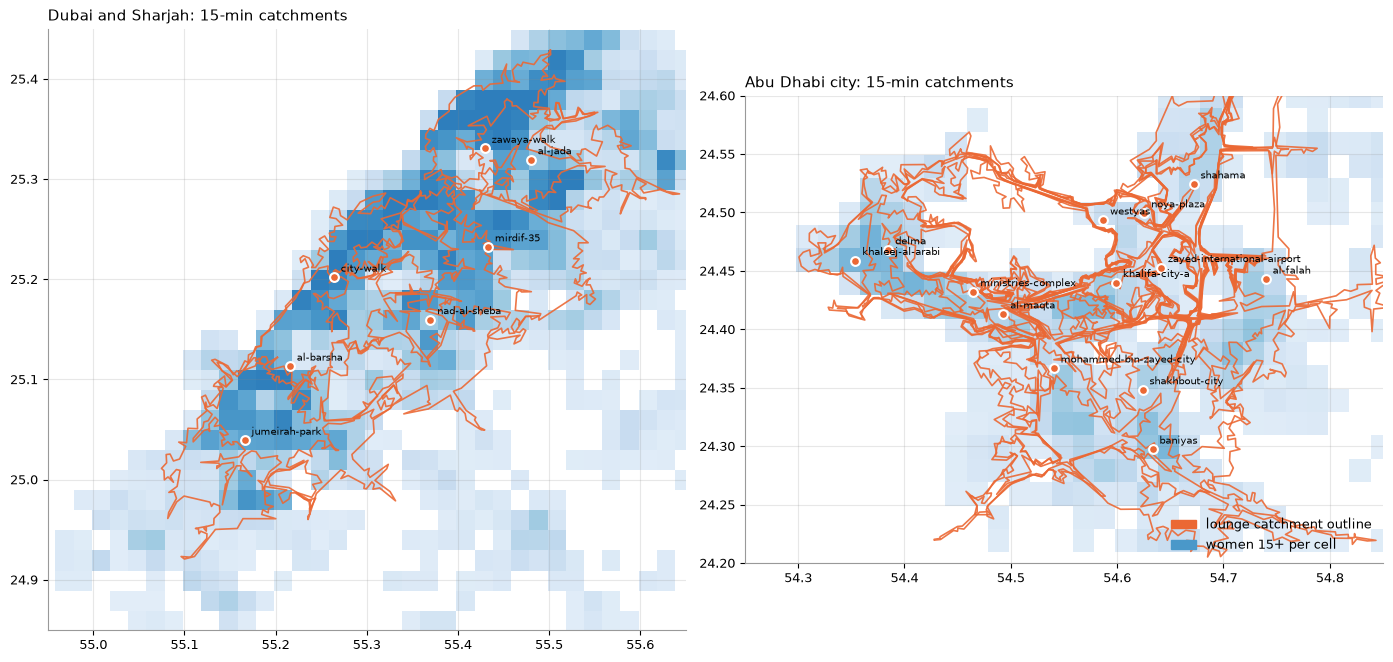

In [3]:
def draw(ax, extent, minutes, title):
    cmap = plt.get_cmap("Blues")
    vmax = np.percentile(cells.women, 99)
    for r in cells.itertuples():
        if extent[0] <= r.lng <= extent[1] and extent[2] <= r.lat <= extent[3]:
            ax.add_patch(Rectangle((r.west, r.south), r.east - r.west, r.north - r.south,
                                   facecolor=cmap(0.1 + 0.6 * min(r.women / vmax, 1)), edgecolor="none"))
    for b, m, g in lounge_iso:
        if m == minutes:
            for part in getattr(g, "geoms", [g]):
                x, y = part.exterior.xy
                ax.plot(x, y, color=ORANGE, lw=1.2, alpha=0.9)
    ax.scatter(branches.lng, branches.lat, s=40, color=ORANGE, edgecolor="white", lw=1.5, zorder=3)
    for b, r in branches.iterrows():
        if extent[0] <= r.lng <= extent[1] and extent[2] <= r.lat <= extent[3]:
            ax.annotate(b, (r.lng, r.lat), xytext=(5, 4), textcoords="offset points", fontsize=7)
    ax.set_xlim(extent[0], extent[1]); ax.set_ylim(extent[2], extent[3]); ax.set_aspect(1 / 0.91)
    ax.set_title(title, loc="left")

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
draw(axes[0], (54.95, 55.65, 24.85, 25.45), LEVELS["medium"], f"Dubai and Sharjah: {LEVELS['medium']}-min catchments")
draw(axes[1], (54.25, 54.85, 24.2, 24.6), LEVELS["medium"], f"Abu Dhabi city: {LEVELS['medium']}-min catchments")
axes[1].legend(handles=[Patch(color=ORANGE, label="lounge catchment outline"),
                        Patch(color=plt.get_cmap("Blues")(0.6), label="women 15+ per cell")],
               loc="lower right", frameon=False)
plt.tight_layout(); plt.show()

## 3. Women in each catchment
Women 15+ in the catchment's cells (worker-housing correction at medium), at each travel time.
This is the **whole** catchment market; Task 4 splits it among the salons that reach each cell.

In [4]:
t = (catch.merge(cells[["women"]], left_on="cell_id", right_index=True)
       .groupby(["branch_id", "level"]).agg(cells=("cell_id", "size"), women=("women", "sum"))
       .unstack("level"))
t.columns = [f"{a}_{b}" for a, b in t.columns]
t = t.reindex(branches.index).fillna(0)
t["emirate"] = branches.emirate
t[[f"women_{l}" for l in LEVELS] + [f"cells_{l}" for l in LEVELS] + ["emirate"]] \
    .sort_values("women_medium", ascending=False).round(0)

,women_low,women_medium,women_high,cells_low,cells_medium,cells_high,emirate
branch_id,,,,,,,
al-barsha,126160.0,272371.0,481992.0,27,64,132,Dubai
city-walk,105298.0,259919.0,488701.0,18,55,103,Dubai
nad-al-sheba,69070.0,247186.0,508323.0,16,63,132,Dubai
mirdif-35,103840.0,241393.0,503015.0,19,51,119,Dubai
zawaya-walk,71301.0,193382.0,398111.0,12,35,82,Sharjah
jumeirah-park,56220.0,171595.0,261220.0,11,39,80,Dubai
al-jada,46212.0,141330.0,296216.0,9,31,77,Sharjah
shakhbout-city,52357.0,134564.0,240058.0,26,70,148,Abu Dhabi
mohammed-bin-zayed-city,31643.0,129056.0,214185.0,15,62,119,Abu Dhabi


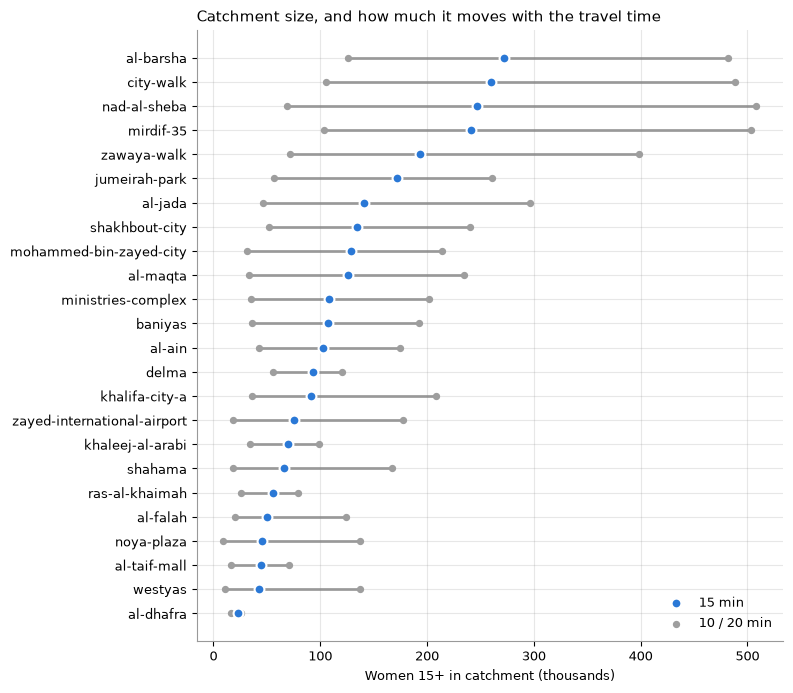

In [5]:
s = t.sort_values("women_medium")
fig, ax = plt.subplots(figsize=(8, 7))
y = np.arange(len(s))
ax.hlines(y, s.women_low / 1000, s.women_high / 1000, color=GREY, lw=2, zorder=1)
ax.scatter(s.women_medium / 1000, y, s=50, color=BLUE, edgecolor="white", lw=1.5, zorder=3, label=f"{LEVELS['medium']} min")
ax.scatter(s.women_low / 1000, y, s=18, color=GREY, zorder=2, label=f"{LEVELS['low']} / {LEVELS['high']} min")
ax.scatter(s.women_high / 1000, y, s=18, color=GREY, zorder=2)
ax.set_yticks(y, s.index)
ax.set_xlabel("Women 15+ in catchment (thousands)")
ax.set_title("Catchment size, and how much it moves with the travel time", loc="left")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout(); plt.show()

## 4. Cannibalisation: catchments shared with another lounge
Share of each lounge's catchment women (medium) who live in cells that another lounge's catchment
also covers. Task 4's market split decides how those women divide; here we only see the overlap.

In [6]:
m = catch[catch.level == "medium"]
n_lounges = m.groupby("cell_id").branch_id.nunique()
m = m.assign(shared=m.cell_id.map(n_lounges) > 1).merge(cells[["women"]], left_on="cell_id", right_index=True)
ov = m.groupby("branch_id").apply(lambda d: d.loc[d.shared, "women"].sum() / d.women.sum(), include_groups=False)
ov = ov.reindex(branches.index).fillna(0).rename("shared_share").to_frame()
pairs = (m.merge(m, on="cell_id").query("branch_id_x < branch_id_y")
          .groupby(["branch_id_x", "branch_id_y"]).women_x.sum().sort_values(ascending=False))
print("lounge pairs sharing the most women (medium):")
print((pairs.head(10) / 1000).round(1).rename("women (k)").to_string())
ov.sort_values("shared_share", ascending=False).round(2)

lounge pairs sharing the most women (medium):
branch_id_x              branch_id_y            
al-barsha                jumeirah-park              125.0
                         city-walk                  114.1
mirdif-35                nad-al-sheba               113.8
city-walk                nad-al-sheba               100.1
al-maqta                 mohammed-bin-zayed-city     99.4
mohammed-bin-zayed-city  shakhbout-city              94.3
baniyas                  shakhbout-city              90.4
al-jada                  zawaya-walk                 90.4
al-maqta                 ministries-complex          87.5
baniyas                  mohammed-bin-zayed-city     72.4


,shared_share
branch_id,
khalifa-city-a,1.00
al-maqta,1.00
noya-plaza,1.00
mohammed-bin-zayed-city,1.00
ministries-complex,1.00
zayed-international-airport,1.00
westyas,0.98
shakhbout-city,0.98
khaleej-al-arabi,0.98


## 5. Competitor search area (Task 4)
The union of every lounge's 2x travel-time polygon. Task 4 sweeps Google for salons inside it.

In [7]:
rows = []
for lvl, m in LEVELS.items():
    union = unary_union([g for b, mm, g in lounge_iso if mm == 2 * m])
    rows.append({"level": lvl, "search_minutes": 2 * m, "area_km2": round(km2(union)),
                 "cells_inside": sum(union.contains(Point(r.lng, r.lat)) for r in cells.itertuples())})
pd.DataFrame(rows).set_index("level")

,search_minutes,area_km2,cells_inside
level,,,
low,20,4076,813
medium,30,8282,1342
high,40,16072,1804


## 6. Growth candidates: people no lounge reaches
Populated cells outside every lounge's catchment (medium), ranked by women. Not a recommendation yet:
Task 4 adds the competitors, which decide whether a gap is open or already served.

In [8]:
covered = set(catch.loc[catch.level == "medium", "cell_id"])
gap = cells[~cells.index.isin(covered)]
print(f"{len(gap):,} of {len(cells):,} populated cells ({gap.women.sum() / cells.women.sum():.0%} of women 15+) "
      f"are outside every {LEVELS['medium']}-min catchment")
print(gap.groupby("emirate").women.sum().sort_values(ascending=False).div(1000).round(0).rename("women outside (k)").to_string())
gap.sort_values("women", ascending=False).head(15)[["name", "emirate", "women", "adults_worker"]].round(0)

1,831 of 2,373 populated cells (49% of women 15+) are outside every 15-min catchment
emirate
Abu Dhabi         494.0
Sharjah           368.0
Dubai             267.0
Ajman             125.0
Ras Al Khaimah     89.0
Fujairah           70.0
Umm Al Quwain      34.0


,name,emirate,women,adults_worker
cell_id,,,,
r36c242,Khor Fakkan,Sharjah,7906.0,160
r39c192,Hor Al Anz,Dubai,7703.0,0
r51c242,Kalba,Sharjah,7553.0,0
r34c199,New Industrial,Ajman,7526.0,0
r32c200,Al Jerf,Ajman,7256.0,0
r38c193,Sharjah,Sharjah,7067.0,0
r30c199,Al Hamriya,Sharjah,6838.0,2887
r37c206,Sharjah,Sharjah,6821.0,27
r36c193,Sharjah,Sharjah,6735.0,0


## 7. Findings

**The geometry is complete.** All 120 lounge polygons (24 lounges x 10/15/20/30/40 min) and all 2,430
cell polygons (810 catchment cells x 10/15/20 min) came back from Mapbox, typical traffic at
weekday 12:00. Committed polygons are simplified to ~200 m; which cells and salons fall inside is
computed on the full-detail polygons.

**Catchment size (women 15+, 15 min, worker-housing correction at medium):**
- Dubai lounges are the largest: al-barsha 272k, city-walk 260k, nad-al-sheba 247k, mirdif-35
  241k (overstated: Sonapur's camps aren't caught, see `market_size.ipynb`), jumeirah-park 172k.
- Sharjah: zawaya-walk 193k, al-jada 141k. Abu Dhabi city lounges 42-135k; al-ain 102k.
- Smallest: al-dhafra 23k (Madinat Zayed, remote), westyas 42k, al-taif-mall 45k, noya-plaza 45k.

**Travel time is the most sensitive assumption.** Going from 15 to 20 min roughly **doubles** most
catchments (nad-al-sheba 247k → 508k), and 10 min roughly halves them. Every number downstream
should be shown at all three levels.

**Cannibalisation is heavy, and it's an Abu Dhabi story.** Every Abu Dhabi city lounge shares
98-100% of its catchment women with another lounge: 13 lounges inside one city's 15-min reach. In
Dubai it's 52-73% (al-barsha & jumeirah-park share 125k women, al-barsha & city-walk 114k,
mirdif-35 & nad-al-sheba 114k). Al-ain, al-dhafra, RAK and Fujairah have no overlap. Task 4's
market split decides how those shared women divide.

**Growth candidates:** 49% of the UAE's women 15+ live outside every 15-min catchment. The
largest gaps by women: Sharjah city and its north (Al Hamriya), Ajman, Hor Al Anz in Deira,
Khor Fakkan and Kalba on the east coast. (Dubai Investments Park also shows up, but it's
largely labour camps the correction misses, so it's overstated.) Competitors (Task 4) decide
which gaps are actually open.

**Competitor search area (Task 4):** the 30-min zones around all lounges cover **8,320 km²** and
1,348 populated cells (40 min: 16,097 km²). That is most of the urban UAE, so the Task 4 probe
and cost estimate matter.

## 8. Examples
Two catchments: a residential one (**city-walk**) and one next to industrial land and labour
housing (**jumeirah-park**: Jebel Ali Industrial and DIP). The map shows the 10 / 15 / 20-min
outlines, the 15-min catchment cells shaded by women 15+, cells where most adults are in worker
housing outlined in orange, and the catchment cell farthest from the lounge (black).

In [9]:
from IPython.display import Markdown, display
from shapely.geometry import box, mapping
from src.features.lounges import haversine_km
from scripts.spot_maps import points, shapes, show

for bid in ["city-walk", "jumeirah-park"]:
    r = branches.loc[bid]
    mine = catch[(catch.branch_id == bid) & (catch.level == "medium")].cell_id
    cc = cells.loc[mine].copy()
    cc["km"] = [haversine_km(r.lat, r.lng, la, ln) for la, ln in zip(cc.lat, cc.lng)]
    cc["worker_share"] = cc.adults_worker / cc.adults
    far = cc.sort_values("km").iloc[-1]
    ind = cc[cc.worker_share > 0.5]
    others = sorted(set(catch[(catch.level == "medium") & catch.cell_id.isin(mine)].branch_id) - {bid})
    display(Markdown(
        f"### {bid}\n"
        f"- **Women 15+ in catchment:** {t.loc[bid, 'women_low']:,.0f} / **{t.loc[bid, 'women_medium']:,.0f}** / {t.loc[bid, 'women_high']:,.0f} (10/15/20 min)\n"
        f"- **Cells (15 min):** {len(cc)}; mostly worker housing: {len(ind)} "
        f"({', '.join(sorted(set(ind['name']))) or 'none'}), holding {ind.adults.sum() / cc.adults.sum():.0%} of the catchment's adults\n"
        f"- **Largest cells by women:** {', '.join(f'{n} ({w / 1000:.1f}k)' for n, w in cc.nlargest(4, 'women')[['name', 'women']].values)}\n"
        f"- **Shares cells with:** {', '.join(others) or 'no other lounge'}\n"
        f"- **Farthest catchment cell:** {far['name']} ({far.lat:.4f}, {far.lng:.4f}), {far.km:.1f} km in a straight line, "
        f"within a {LEVELS['medium']}-min drive at midday"))
    vmax = cc.women.max()
    cell_feats = [{"type": "Feature", "geometry": mapping(box(x.west, x.south, x.east, x.north)),
                   "properties": {"label": f"{x['name']}: {x.women:,.0f} women, {x.worker_share:.0%} worker housing",
                                  "fill": [42, 120, 214, int(30 + 170 * x.women / vmax)]}} for _, x in cc.iterrows()]
    ind_feats = [{"type": "Feature", "geometry": mapping(box(x.west, x.south, x.east, x.north)),
                  "properties": {"label": f"{x['name']}: worker housing {x.worker_share:.0%}"}} for _, x in ind.iterrows()]
    iso = [{"type": "Feature", "geometry": mapping(g), "properties": {"label": f"{m}-min drive"}}
           for b, m, g in lounge_iso if b == bid and m in LEVELS.values()]
    display(show([shapes(cell_feats, fill="properties.fill", line=(255, 255, 255)),
                  shapes(ind_feats, fill=(0, 0, 0, 0), line=(235, 104, 52)),
                  shapes(iso, fill=(0, 0, 0, 0), line=(60, 60, 60)),
                  points([{"lat": r.lat, "lng": r.lng, "label": bid, "r": 250}], (235, 104, 52)),
                  points([{"lat": far.lat, "lng": far.lng, "label": f"farthest cell: {far['name']}", "r": 200}], (40, 40, 40))],
                 r.lat, r.lng, zoom=10.6, height=520))

### city-walk
- **Women 15+ in catchment:** 105,298 / **259,919** / 488,701 (10/15/20 min)
- **Cells (15 min):** 55; mostly worker housing: 3 (Al Quoz Community), holding 4% of the catchment's adults
- **Largest cells by women:** Hor Al Anz (8.5k), Al Satwa (8.5k), Jumeirah (8.0k), Al Barsha (8.0k)
- **Shares cells with:** al-barsha, jumeirah-park, mirdif-35, nad-al-sheba
- **Farthest catchment cell:** Ras Al Khor Industrial 3 (25.1792, 55.3883), 12.8 km in a straight line, within a 15-min drive at midday

### jumeirah-park
- **Women 15+ in catchment:** 56,220 / **171,595** / 261,220 (10/15/20 min)
- **Cells (15 min):** 39; mostly worker housing: 4 (Jabal Ali 1, Jabal Ali Industrial 1, Jebel Ali Industrial Area), holding 12% of the catchment's adults
- **Largest cells by women:** Al Barsha (8.0k), Al Barsha 3 (7.4k), Dubai Knowledge Park (7.2k), Al Barsha South 4 (7.1k)
- **Shares cells with:** al-barsha, city-walk
- **Farthest catchment cell:** Dubai (24.9592, 55.1483), 9.1 km in a straight line, within a 15-min drive at midday